## 1.Required Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

## 2.Loading Dataset

In [2]:
data = pd.read_csv('online_retail.csv')
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


## 3.Learning Basic Information about data

In [3]:
data.shape

(541909, 8)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
data.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [6]:
data.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

### We have missing data's of 1452 and 135080 in Description and CustomerID Column respectively

In [7]:
print(f'% of Description Missing value : {((data['Description'].isnull().sum()) / len(data)) * 100}')
print(f'% of CustomerID Missing value : {((data['CustomerID'].isnull().sum()) / len(data)) * 100}')

% of Description Missing value : 0.2683107311375157
% of CustomerID Missing value : 24.926694334288598


### The Missing Column are Description and CustomerID.

### Description is missing 0.2 % of total dataset

### CustomerID is missing 24.9 % of total dataset

In [8]:
data.duplicated().sum()

np.int64(5268)

### We have 5268 duplicate values

In [9]:
print(f'% of Duplicate value : {((data.duplicated().sum()) / len(data)) * 100}')

% of Duplicate value : 0.9721189350979592


### % of Duplicate  values 0.9 % of total dataset

In [10]:
data[data['CustomerID'].isnull()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2022-12-01 11:52:00,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2022-12-01 14:32:00,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2022-12-01 14:32:00,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2022-12-01 14:32:00,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2022-12-01 14:32:00,1.66,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
541536,581498,85099B,JUMBO BAG RED RETROSPOT,5,2023-12-09 10:26:00,4.13,NaN,United Kingdom
541537,581498,85099C,JUMBO BAG BAROQUE BLACK WHITE,4,2023-12-09 10:26:00,4.13,NaN,United Kingdom
541538,581498,85150,LADIES & GENTLEMEN METAL SIGN,1,2023-12-09 10:26:00,4.96,NaN,United Kingdom
541539,581498,85174,S/4 CACTI CANDLES,1,2023-12-09 10:26:00,10.79,NaN,United Kingdom


### Seeing the Unique values and N_Unique values in dataset

In [11]:
for col in data.columns:
  print(f"{col}:\n Unique values:",data[col].nunique(),"\n", data[col].unique())
  print()
  print()

InvoiceNo:
 Unique values: 25900 
 ['536365' '536366' '536367' ... '581585' '581586' '581587']


StockCode:
 Unique values: 4070 
 ['85123A' '71053' '84406B' ... '90214U' '47591b' '23843']


Description:
 Unique values: 4223 
 ['WHITE HANGING HEART T-LIGHT HOLDER' 'WHITE METAL LANTERN'
 'CREAM CUPID HEARTS COAT HANGER' ... 'lost'
 'CREAM HANGING HEART T-LIGHT HOLDER' 'PAPER CRAFT , LITTLE BIRDIE']


Quantity:
 Unique values: 722 
 [     6      8      2     32      3      4     24     12     48     18
     20     36     80     64     10    120     96     23      5      1
     -1     50     40    100    192    432    144    288    -12    -24
     16      9    128     25     30     28      7     56     72    200
    600    480     -6     14     -2     11     33     13     -4     -5
     -7     -3     70    252     60    216    384    -10     27     15
     22     19     17     21     34     47    108     52  -9360    -38
     75    270     42    240     90    320   1824    204     69    -

In [12]:
# Converting InvoiceDate to datetime dtype
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

In [13]:
# checking the InvoiceNo column for involid cancelled invoice no
data[data['InvoiceNo'].astype(str).str.startswith('C')].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2022-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2022-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2022-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2022-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2022-12-01 10:24:00,0.29,17548.0,United Kingdom


In [14]:
print(f"CustomerID that are missing : {len(data[data['InvoiceNo'].astype(str).str.startswith('C')])}")

CustomerID that are missing : 9288


In [15]:
# Taking only the valid Invoice and avoiding the Cancelled invoice
data = data[~data['InvoiceNo'].astype(str).str.startswith('C')]

In [16]:
print(f"No of Quantity less then zero : {len(data['Quantity'] > 0)}")
print(f"No of UnitPrice less then zero : {len(data['UnitPrice'] > 0)}")

No of Quantity less then zero : 532621
No of UnitPrice less then zero : 532621


In [17]:
# Taking only the valid positive quantitya and unitprice
data = data[(data['Quantity'] > 0) & (data['UnitPrice'] > 0)]

In [18]:
data = data[data["CustomerID"].astype(str).str.strip() != ""]

In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 530104 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    530104 non-null  object        
 1   StockCode    530104 non-null  object        
 2   Description  530104 non-null  object        
 3   Quantity     530104 non-null  int64         
 4   InvoiceDate  530104 non-null  datetime64[ns]
 5   UnitPrice    530104 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      530104 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 36.4+ MB


## 4.EDA

In [20]:
# Seeing Numerical Columns correlation
numerical_col = ['Quantity','UnitPrice','CustomerID']
nume_corr = data[numerical_col].corr()
nume_corr

,Quantity,UnitPrice,CustomerID
Quantity,1.000000,-0.003773,-0.006232
UnitPrice,-0.003773,1.000000,-0.010873
CustomerID,-0.006232,-0.010873,1.000000


In [21]:
# Checking country wise orders count
country_order_count = data['Country'].value_counts().sort_values(ascending=False).reset_index()
country_order_count = country_order_count.rename(columns={"count":"Total_Customers"})
country_order_count

,Country,Total_Customers
0,United Kingdom,485123
1,Germany,9040
2,France,8407
3,EIRE,7890
4,Spain,2484
5,Netherlands,2359
6,Belgium,2031
7,Switzerland,1966
8,Portugal,1501
9,Australia,1182


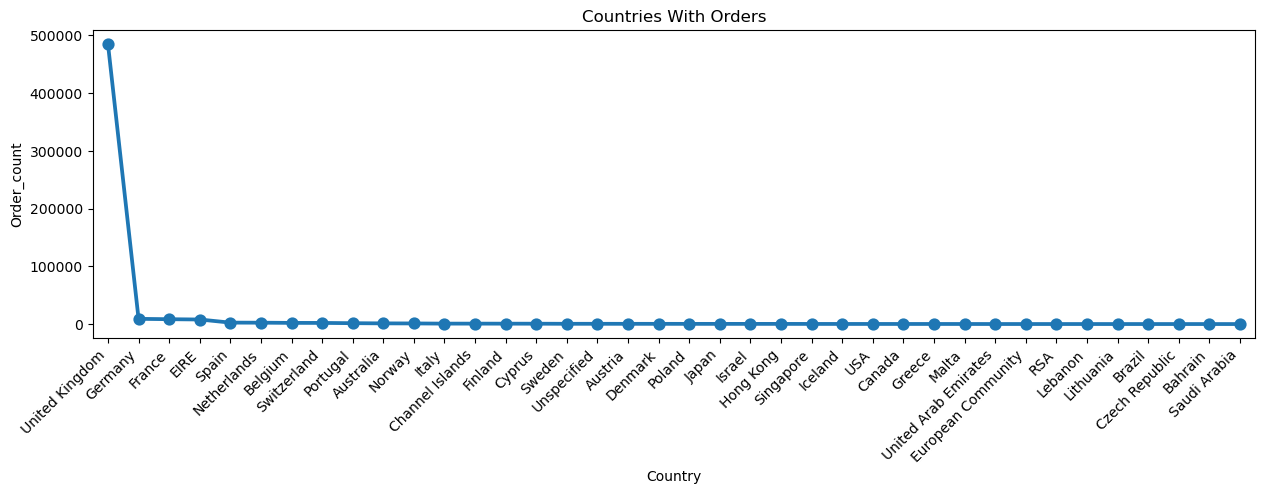

In [22]:
plt.figure(figsize= (15,4))
sns.pointplot(x=country_order_count['Country'],y=country_order_count['Total_Customers'],markers='o')
plt.title("Countries With Orders")
plt.xlabel('Country')
plt.ylabel('Order_count')
plt.xticks(rotation=45,ha='right')
plt.show()

In [23]:
# Grouping by the Description with its total quantity
grouped_description = data.groupby('Description')['Quantity'].sum().reset_index().sort_values(by='Quantity',ascending=False)
grouped_description = grouped_description.rename(columns={"Quantity":"Total_Quantity"})
grouped_description

,Description,Total_Quantity
2387,"PAPER CRAFT , LITTLE BIRDIE",80995
2052,MEDIUM CERAMIC TOP STORAGE JAR,78033
3934,WORLD WAR 2 GLIDERS ASSTD DESIGNS,55047
1816,JUMBO BAG RED RETROSPOT,48474
3844,WHITE HANGING HEART T-LIGHT HOLDER,37891
...,...,...
472,BLUE NEW BAROQUE FLOCK CANDLESTICK,1
2535,PINK FEATHER CHRISTMAS DECORATION,1
3280,SET/6 IVORY BIRD T-LIGHT CANDLES,1
2518,PINK CRYSTAL GUITAR PHONE CHARM,1


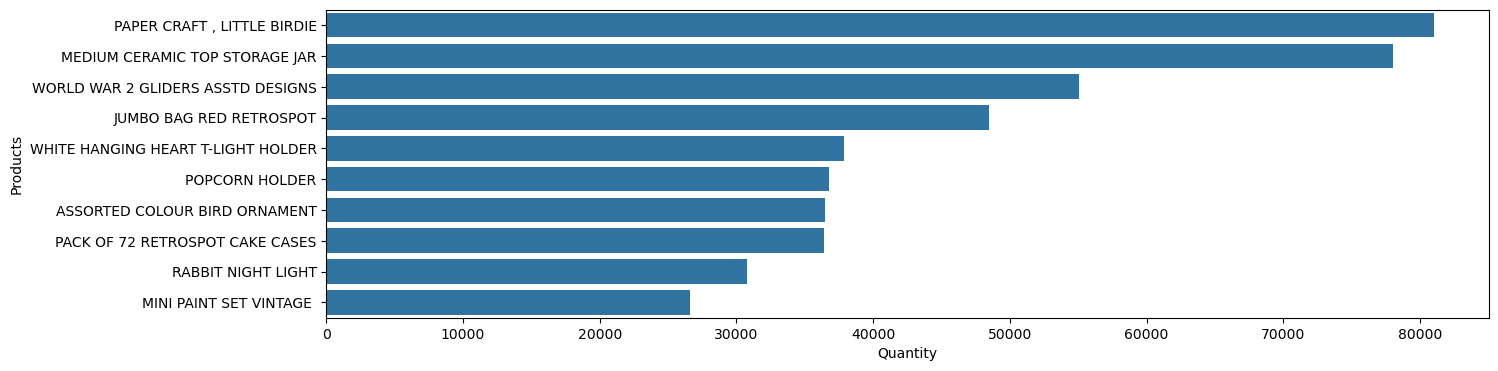

In [24]:
plt.figure(figsize=(15,4))
sns.barplot(x=grouped_description['Total_Quantity'].head(10),y=grouped_description['Description'].head(10))
plt.ylabel('Products')
plt.xlabel('Quantity')
plt.show()

In [25]:
# Checking on the year range in the dataset
year = data['InvoiceDate'].dt.year
print(year.unique())

[2022 2023]


In [26]:
# Group by year and calculate the sum of value for each year
yearly_sum = data.groupby(year)['CustomerID'].nunique().reset_index()
yearly_sum = yearly_sum.rename(columns={"InvoiceDate":"Year","CustomerID":"Total_Customers"})
print(yearly_sum)

   Year  Total_Customers
0  2022              885
1  2023             4219


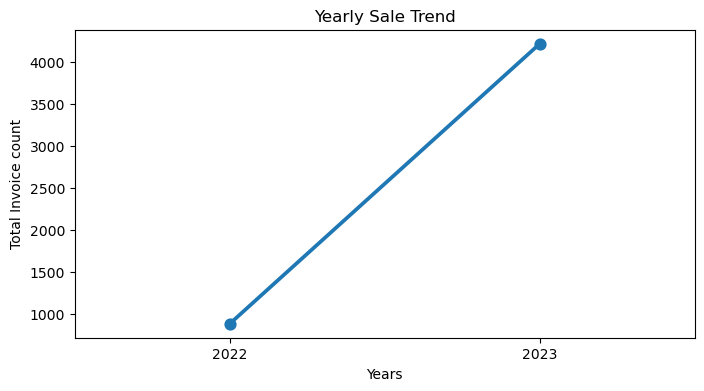

In [27]:
plt.figure(figsize=(8,4))
sns.pointplot(x=yearly_sum['Year'],y= yearly_sum['Total_Customers'])
plt.title('Yearly Sale Trend')
plt.xlabel('Years')
plt.ylabel('Total Invoice count')
plt.show()

In [28]:
# Group by month and calculate the sum of value for each month
monthly_sum = data.groupby([data['InvoiceDate'].dt.month])['CustomerID'].nunique().reset_index()
monthly_sum = monthly_sum.rename(columns={"InvoiceDate":"Month","CustomerID":"Total_Customers"})
monthly_sum

,Month,Total_Customers
0,1,741
1,2,758
2,3,974
3,4,856
4,5,1056
5,6,991
6,7,949
7,8,935
8,9,1266
9,10,1364


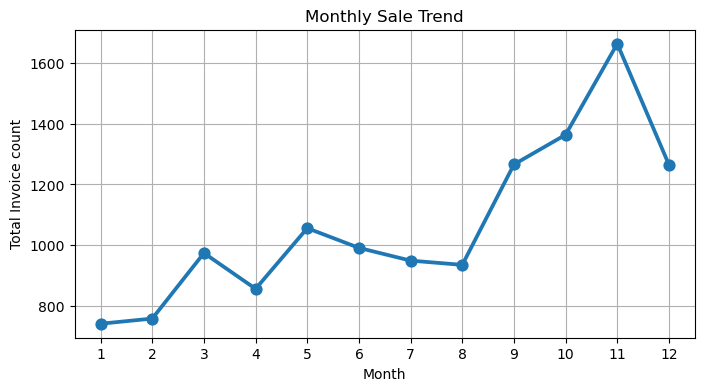

In [29]:
plt.figure(figsize=(8,4))
sns.pointplot(x=monthly_sum["Month"],y=monthly_sum["Total_Customers"])
plt.title('Monthly Sale Trend')
plt.xlabel('Month')
plt.ylabel('Total Invoice count')
plt.grid()
plt.show()

In [30]:
# Calculating the total amount of that each customer spend for item
data['Total_amount'] = data['Quantity'] * data['UnitPrice']

In [31]:
# Grouping by the CustomerID and there total amount spent by them
customer_total = data.groupby(['CustomerID'])['Total_amount'].sum().sort_values(ascending=False).reset_index()
customer_total = customer_total.rename(columns={"Total_amount":"Total_amount_spent"})
customer_total

,CustomerID,Total_amount_spent
0,14646.0,280206.02
1,18102.0,259657.30
2,17450.0,194550.79
3,16446.0,168472.50
4,14911.0,143825.06
...,...,...
4333,16878.0,13.30
4334,17956.0,12.75
4335,16454.0,6.90
4336,14792.0,6.20


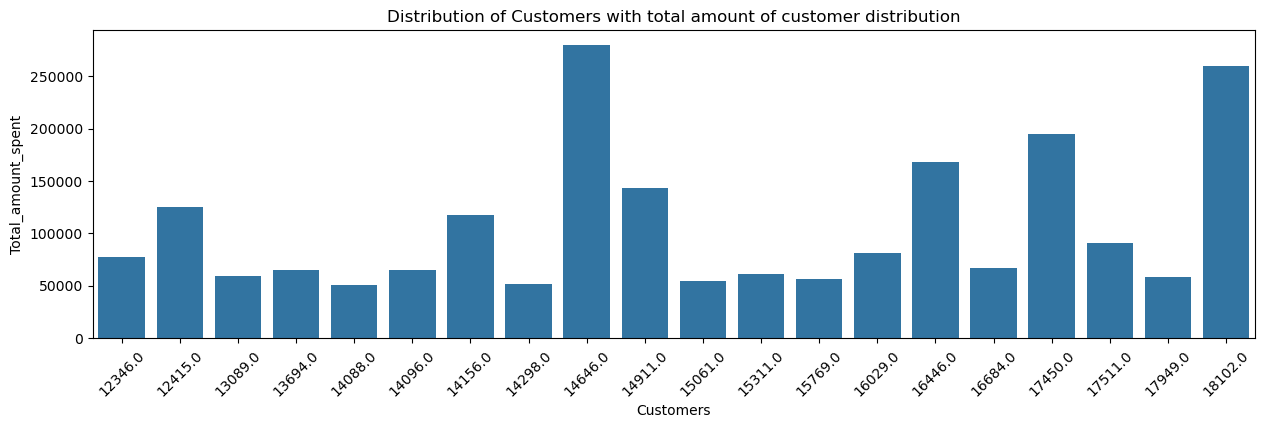

In [32]:
plt.figure(figsize=(15,4))
sns.barplot(data=customer_total.head(20),x="CustomerID",y="Total_amount_spent")
plt.title('Distribution of Customers with total amount of customer distribution')
plt.xlabel('Customers')
plt.ylabel('Total_amount_spent')
plt.xticks(rotation=45)
plt.show()

In [33]:
data.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Total_amount'],
      dtype='object')

## 5.RFM Analysis

In [34]:
# See the recent Invoice Date
data['InvoiceDate'].max()

Timestamp('2023-12-09 12:50:00')

In [35]:
# Creating the RFM['Recency','Frequency','Monetary'] dataframe
rfm = pd.DataFrame()

# Finding the recently when customer billing happened based on max invoicedate and recent invoicedate of customer then converting in term of day.
rfm['Recency'] = data.groupby('CustomerID').agg({'InvoiceDate':lambda x :(data['InvoiceDate'].max() - x.max()).days}) 

# Finding the customer frequency of visit with number of invoices
rfm['Frequency'] = data.groupby('CustomerID').agg({'InvoiceNo':'nunique'})

# Finding the customer total money spent by suming total_amount
rfm['Monetary'] = data.groupby('CustomerID').agg({'Total_amount':'sum'})

In [36]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,1,77183.60
12347.0,1,7,4310.00
12348.0,74,4,1797.24
12349.0,18,1,1757.55
12350.0,309,1,334.40


In [37]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4338 entries, 12346.0 to 18287.0
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Recency    4338 non-null   int64  
 1   Frequency  4338 non-null   int64  
 2   Monetary   4338 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 135.6 KB


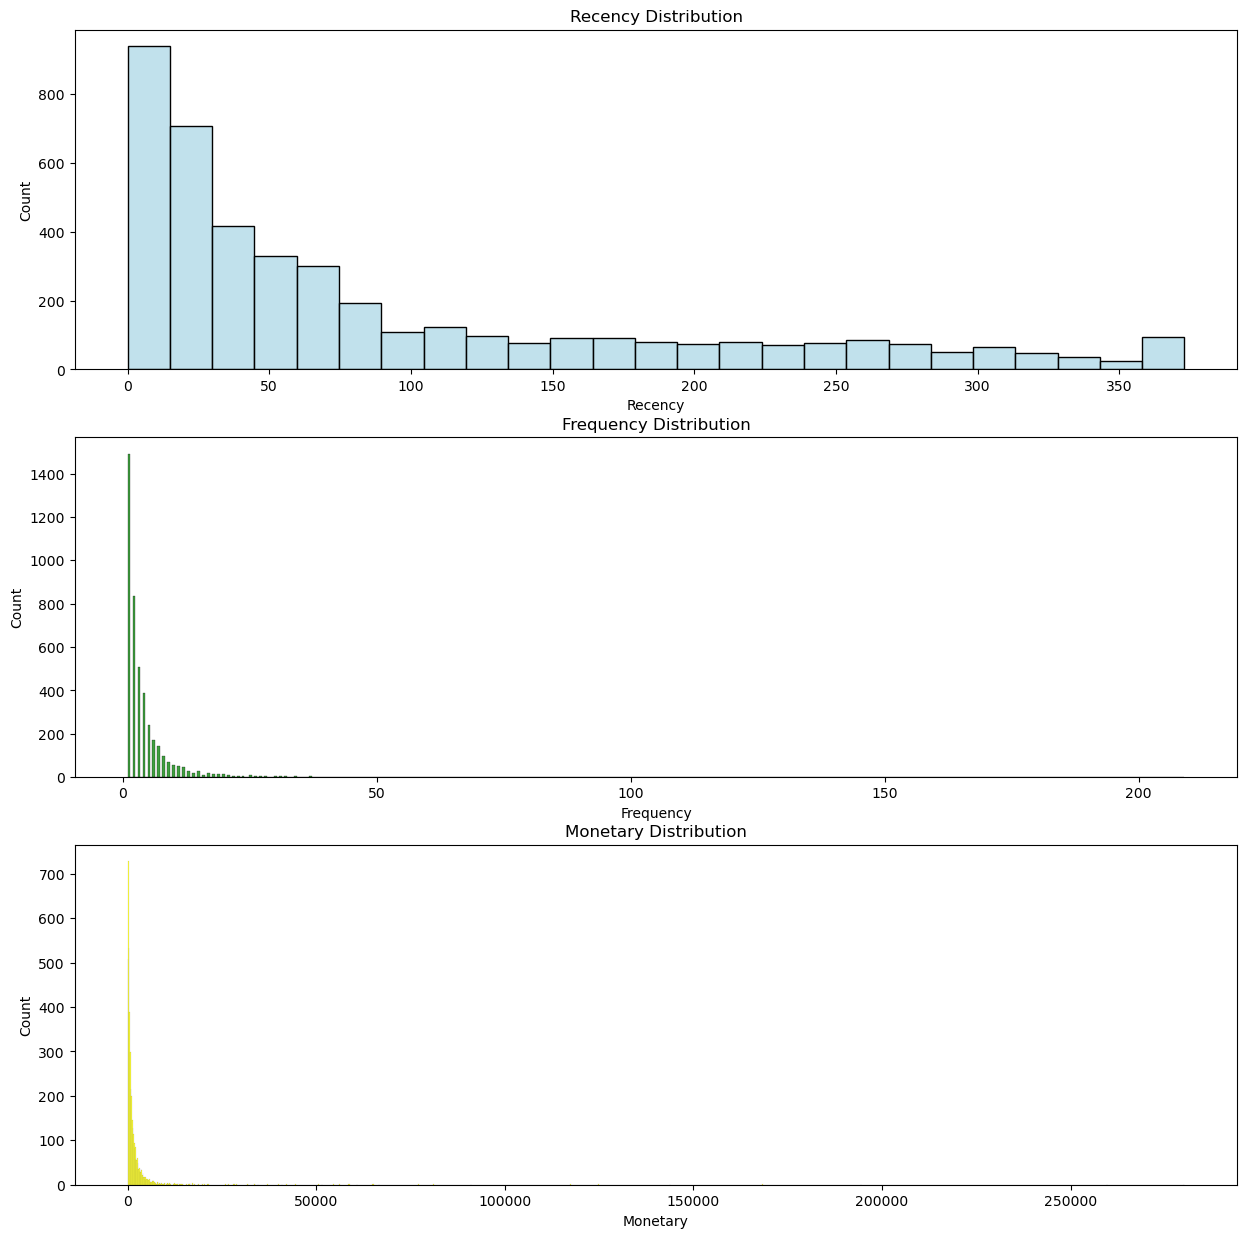

In [38]:
# Plotting of the RFM Distribution

plt.figure(figsize=(15,15))
plt.subplot(3,1,1)
plt.title('Recency Distribution')
sns.histplot(data = rfm,x='Recency',color='lightblue')

plt.subplot(3,1,2)
plt.title('Frequency Distribution')
sns.histplot(data = rfm,x='Frequency',color='green')

plt.subplot(3,1,3)
plt.title('Monetary Distribution')
sns.histplot(data = rfm,x='Monetary',color='yellow')
plt.show()

In [39]:
# Transforming the RFM with log1p to visually get to see in plot

log_rfm = pd.DataFrame()
log_rfm['Recency'] = np.log1p(rfm['Recency'])
log_rfm['Frequency'] = np.log1p(rfm['Frequency'])
log_rfm['Monetary'] = np.log1p(rfm['Monetary'])

In [40]:
log_rfm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4338 entries, 12346.0 to 18287.0
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Recency    4338 non-null   float64
 1   Frequency  4338 non-null   float64
 2   Monetary   4338 non-null   float64
dtypes: float64(3)
memory usage: 135.6 KB


In [41]:
log_rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,3.767534,1.345582,6.593627
std,1.432445,0.683104,1.257578
min,0.000000,0.693147,1.558145
25%,2.890372,0.693147,5.731446
50%,3.931826,1.098612,6.515431
75%,4.955827,1.791759,7.416222
max,5.924256,5.347108,12.543284


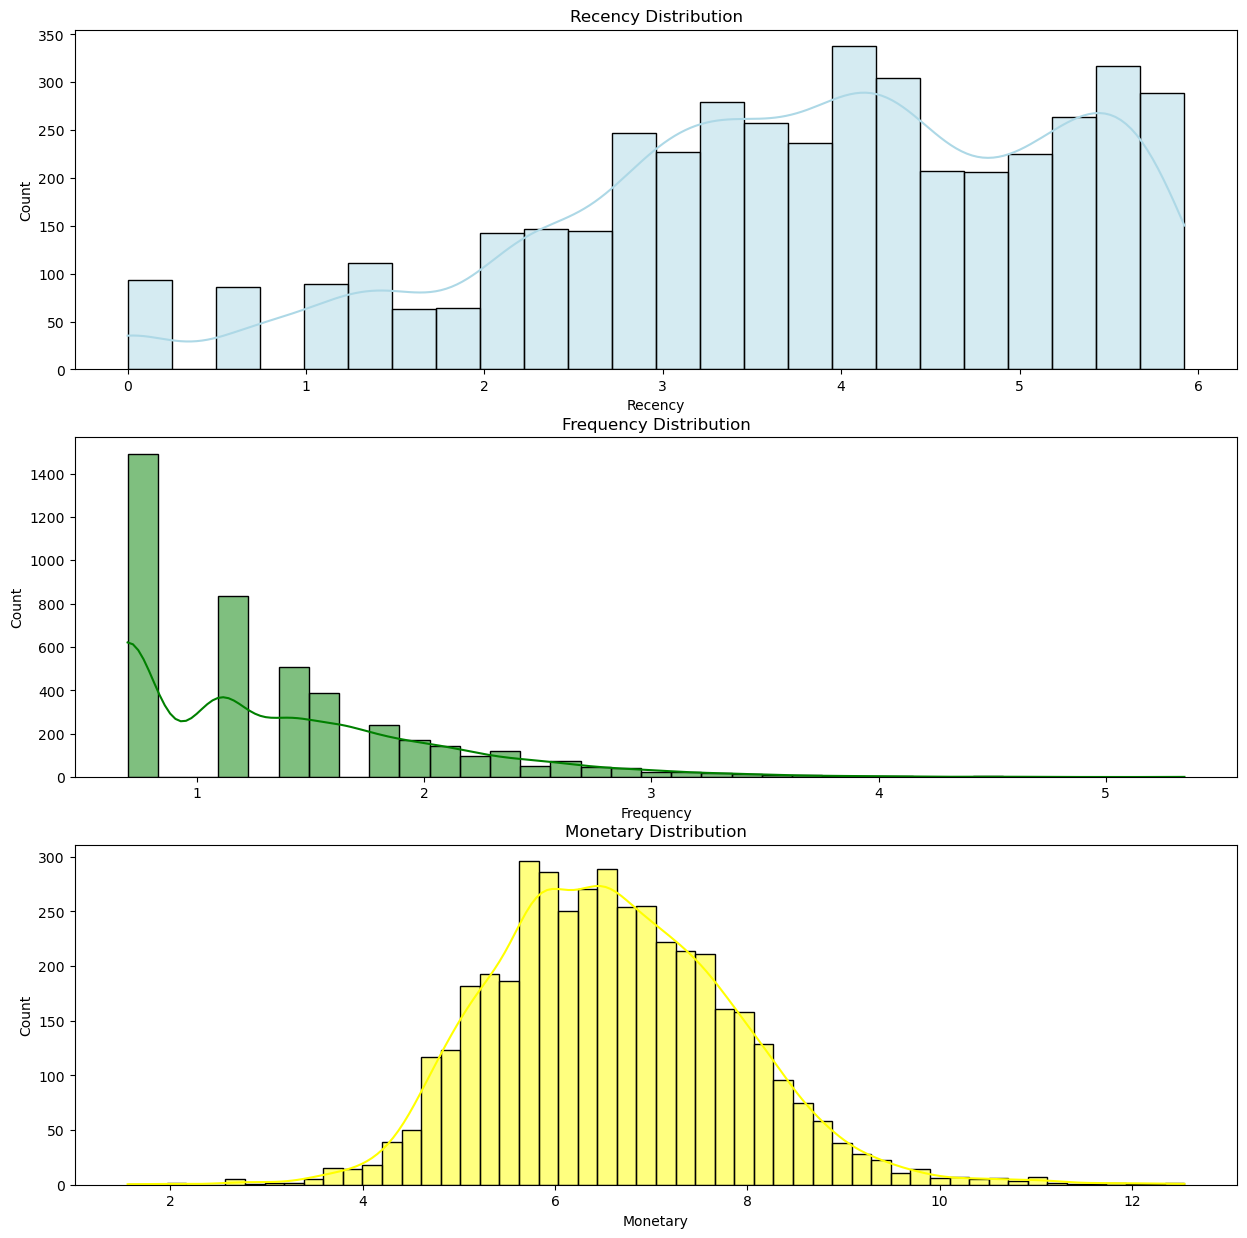

In [42]:
plt.figure(figsize=(15,15))
plt.subplot(3,1,1)
plt.title('Recency Distribution')
sns.histplot(data = log_rfm,x='Recency',kde=True,color='lightblue')

plt.subplot(3,1,2)
plt.title('Frequency Distribution')
sns.histplot(data = log_rfm,x='Frequency',kde=True,color='green')

plt.subplot(3,1,3)
plt.title('Monetary Distribution')
sns.histplot(data = log_rfm,x='Monetary',kde=True,color='yellow')
plt.show()

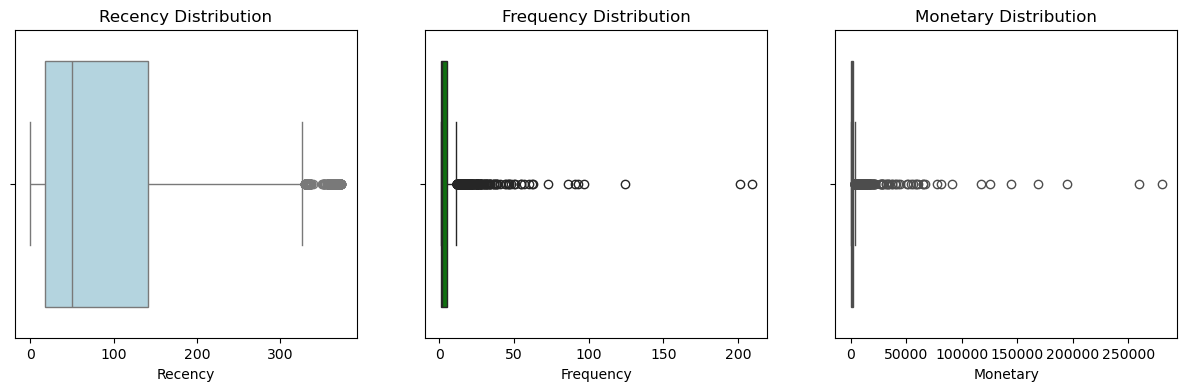

In [43]:
plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
plt.title('Recency Distribution')
sns.boxplot(data = rfm,x='Recency',color='lightblue')

plt.subplot(1,3,2)
plt.title('Frequency Distribution')
sns.boxplot(data = rfm,x='Frequency',color='green')

plt.subplot(1,3,3)
plt.title('Monetary Distribution')
sns.boxplot(data = rfm,x='Monetary',color='yellow')
plt.show()

In [44]:
# Handling Outliers
def IQR(col):
    q1=rfm[col].quantile(0.25)
    q3=rfm[col].quantile(0.75)
    IQR = q3-q1
    lower_bound = q1 - 1.5 * IQR
    upper_bound = q3 + 1.5 * IQR
    rfm[col] = np.clip(rfm[col],lower_bound,upper_bound)

IQR('Recency')
IQR('Frequency')
IQR('Monetary')

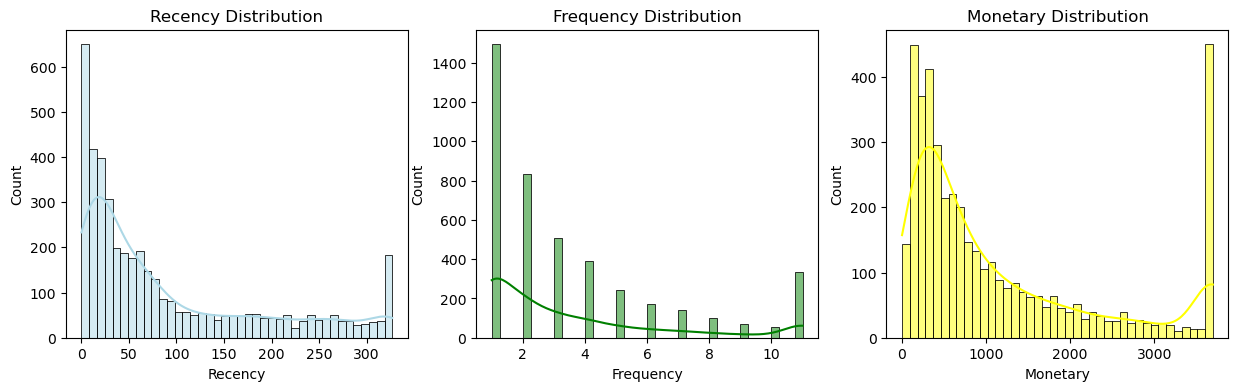

In [45]:
plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
plt.title('Recency Distribution')
sns.histplot(data = rfm,x='Recency',bins=40,kde=True,color='lightblue')

plt.subplot(1,3,2)
plt.title('Frequency Distribution')
sns.histplot(data = rfm,x='Frequency',bins=40,kde=True,color='green')

plt.subplot(1,3,3)
plt.title('Monetary Distribution')
sns.histplot(data = rfm,x='Monetary',bins=40,kde=True,color='yellow')
plt.show()

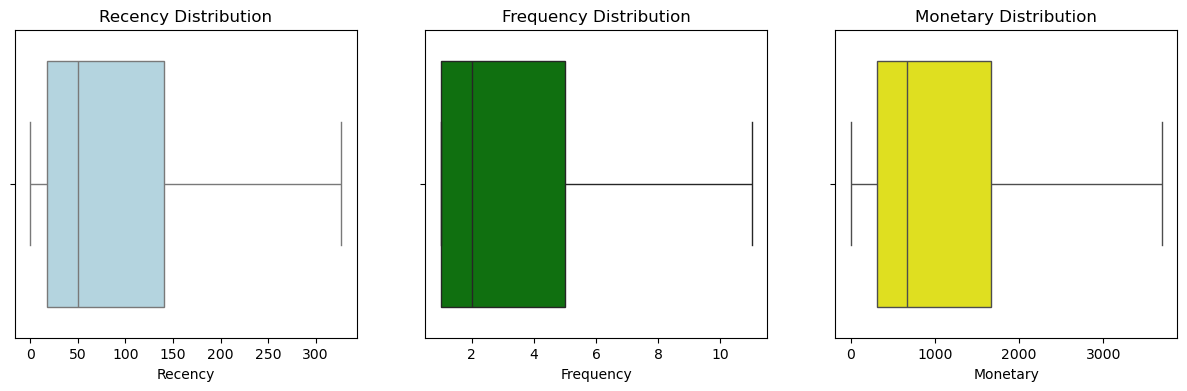

In [46]:
plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
plt.title('Recency Distribution')
sns.boxplot(data = rfm,x='Recency',color='lightblue')

plt.subplot(1,3,2)
plt.title('Frequency Distribution')
sns.boxplot(data = rfm,x='Frequency',color='green')

plt.subplot(1,3,3)
plt.title('Monetary Distribution')
sns.boxplot(data = rfm,x='Monetary',color='yellow')
plt.show()

## 6.Clustering

In [47]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)
print(rfm_scaled)

[[ 2.41338159 -0.81803497  2.20422377]
 [-0.92035154  1.15580523  2.20422377]
 [-0.16923265  0.16888513  0.55257938]
 ...
 [-0.85861574 -0.4890616  -0.85793945]
 [-0.89977294  2.4716987   0.81186139]
 [-0.49849025 -0.16008824  0.58745928]]


In [48]:
inertia = []
K_range = range(2,11)
silhouette_scores = []
best_score = -1
best_k = -1

for k in K_range:
    kmeans = KMeans(n_clusters=k,random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)
    
    score = silhouette_score(rfm_scaled,kmeans.labels_)
    silhouette_scores.append(score)
    
    print(f"k = {k}, Silhouette Score = {score:.3f}")
    # Check if this is the best score so far
    if score > best_score:
        best_score = score
        best_k = k

print(f"\nOptimal number of clusters is k = {best_k} with a Silhouette Score of {best_score:.3f}")

C:\Users\SDP87\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\SDP87\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\SDP87\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\SDP87\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

k = 2, Silhouette Score = 0.506
k = 3, Silhouette Score = 0.510
k = 4, Silhouette Score = 0.474
k = 5, Silhouette Score = 0.423
k = 6, Silhouette Score = 0.424
k = 7, Silhouette Score = 0.423
k = 8, Silhouette Score = 0.416
k = 9, Silhouette Score = 0.366
k = 10, Silhouette Score = 0.359

Optimal number of clusters is k = 3 with a Silhouette Score of 0.510


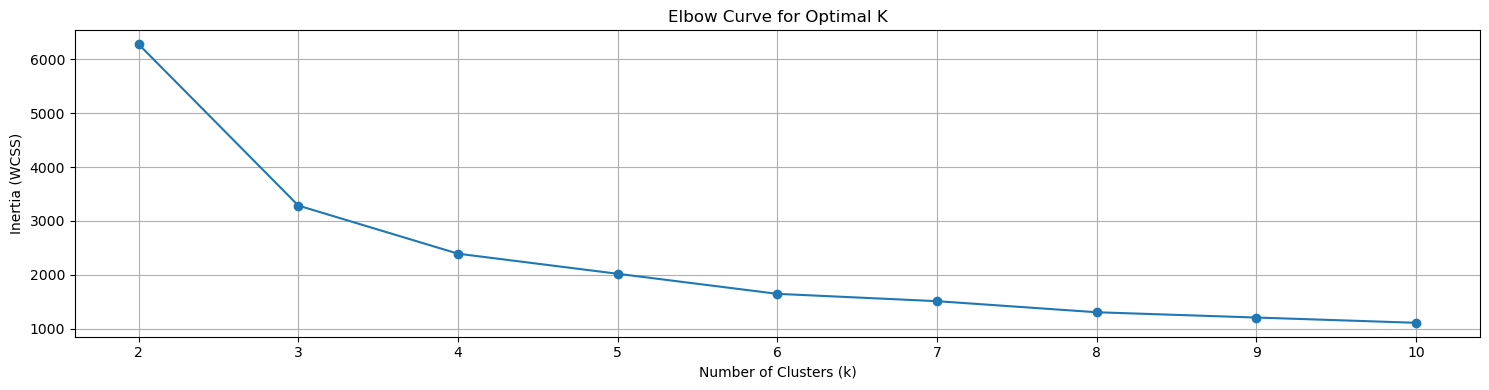

In [49]:
plt.figure(figsize=(15,4))
plt.plot(K_range,inertia,marker='o')
plt.title('Elbow Curve for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(K_range)
plt.grid(True)
plt.tight_layout()
plt.show()

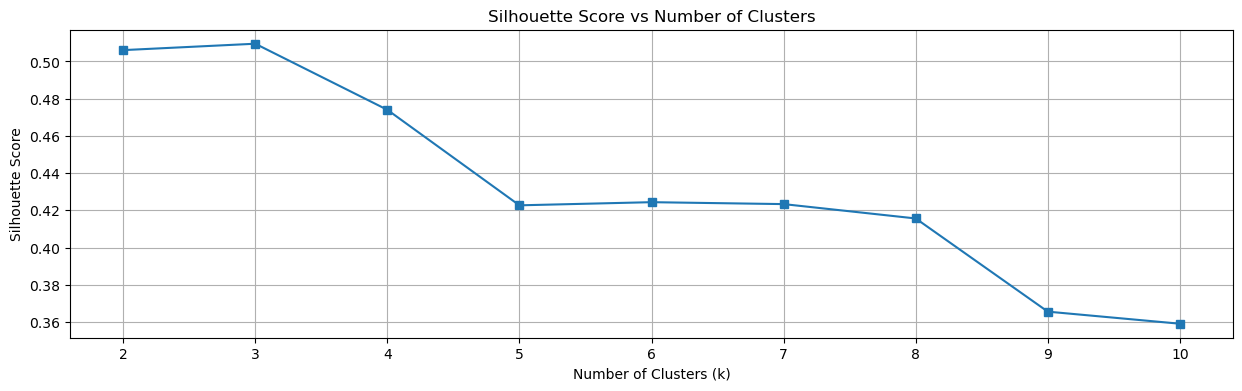

In [50]:
plt.figure(figsize=(15,4))
plt.plot(K_range,silhouette_scores,marker='s')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Number of Clusters')
plt.grid(True)
plt.show()

In [51]:
optimal_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init='auto')
rfm['Cluster'] = optimal_kmeans.fit_predict(rfm_scaled)

# You can now analyze the clusters by grouping by the 'Cluster' column
rfm_clusters = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)

print("\nRFM Clusters Summary:")
print(rfm_clusters)


RFM Clusters Summary:
         Recency  Frequency  Monetary
Cluster                              
0          47.97       2.46    731.49
1          25.90       8.16   3008.21
2         243.86       1.47    427.68


In [52]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,325,1,3693.2275,2
12347.0,1,7,3693.2275,1
12348.0,74,4,1797.2400,0
12349.0,18,1,1757.5500,0
12350.0,309,1,334.4000,2


In [53]:
cluster_labels = {
    0: 'Regular',
    1: 'High-Value',
    2: 'At-Risk'
}

rfm['Segment'] = rfm['Cluster'].map(cluster_labels)

## Cluster 0: Regular Customers
    Recency: 47.97 (A moderate value, meaning they haven't purchased very recently).
    Frequency: 2.46 (A moderate value).
    Monetary: 731.49 (A high value, indicating good spending habits).

## Cluster 1: High-Value Customers
    Recency: 25.90 (Lowest value, meaning they've purchased most recently).
    Frequency: 8.16 (Highest value, meaning they purchase most frequently).
    Monetary: 3008.21 (Highest value, meaning they spend the most money).

## Cluster 2: At-Risk Customers
    Recency: 243.86 (A low value, meaning they've purchased somewhat recently).
    Frequency: 1.47 (A low value).
    Monetary: 427.68 (A low value).

In [54]:
rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,325,1,3693.2275,2,At-Risk
12347.0,1,7,3693.2275,1,High-Value
12348.0,74,4,1797.2400,0,Regular
12349.0,18,1,1757.5500,0,Regular
12350.0,309,1,334.4000,2,At-Risk


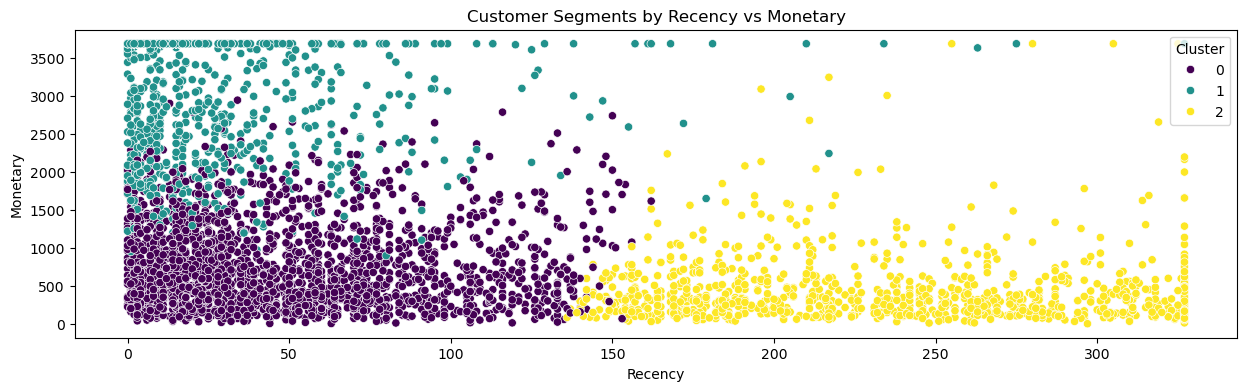

In [55]:
plt.figure(figsize=(15,4))
sns.scatterplot(data=rfm, x='Recency',y='Monetary',hue='Cluster', palette='viridis')
plt.title('Customer Segments by Recency vs Monetary')
plt.show()

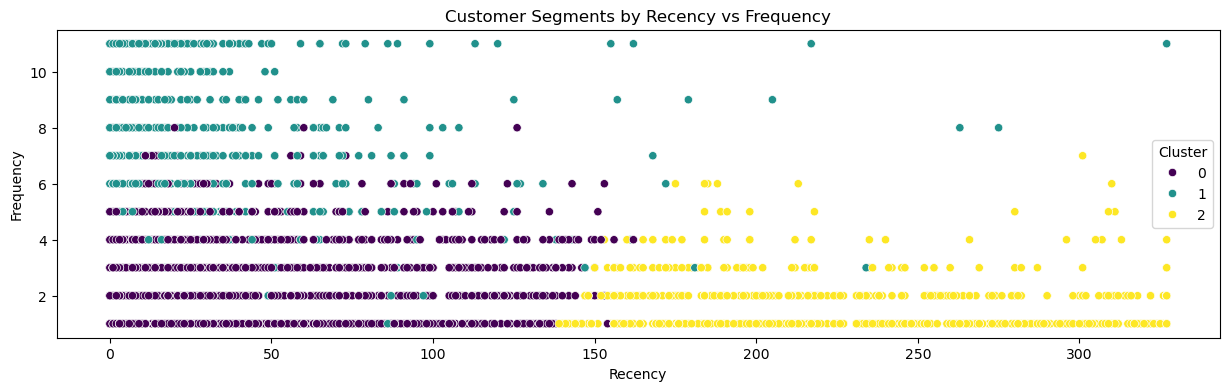

In [56]:
plt.figure(figsize=(15,4))
sns.scatterplot(data=rfm, x='Recency',y='Frequency',hue='Cluster', palette='viridis')
plt.title('Customer Segments by Recency vs Frequency')
plt.show()

In [57]:
fig = px.scatter_3d(
    rfm,
    x='Recency',
    y='Frequency',
    z='Monetary',
    color='Cluster',  # or use 'Segment' if you've labeled clusters
    title='3D RFM Cluster Visualization',
    opacity=0.8,
    color_continuous_scale='viridis'
)

fig.show()

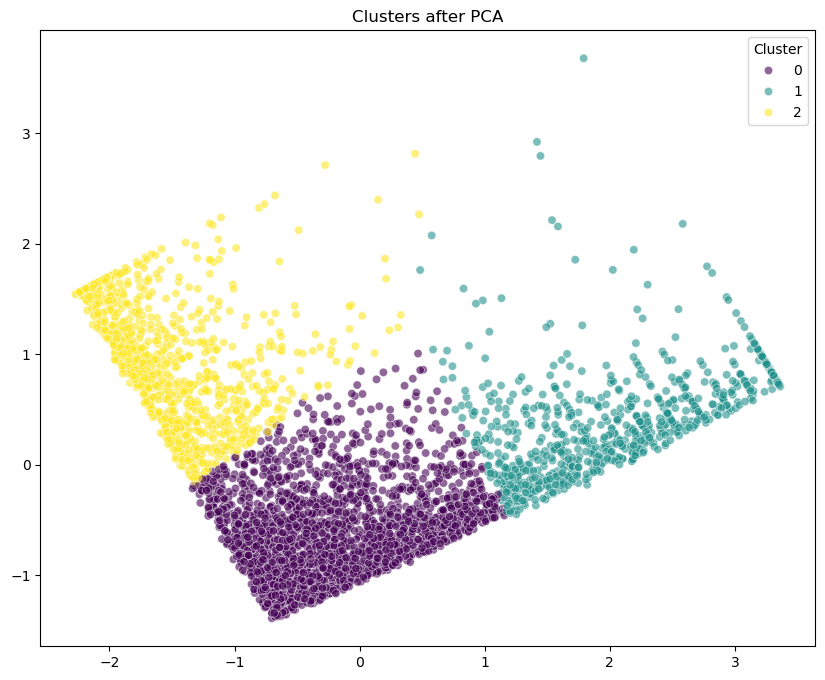

In [58]:
# Visualize clusters using PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(rfm_scaled)

plt.figure(figsize=(10,8))
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=rfm["Cluster"], palette="viridis",alpha=0.6)
plt.title("Clusters after PCA")
plt.show()

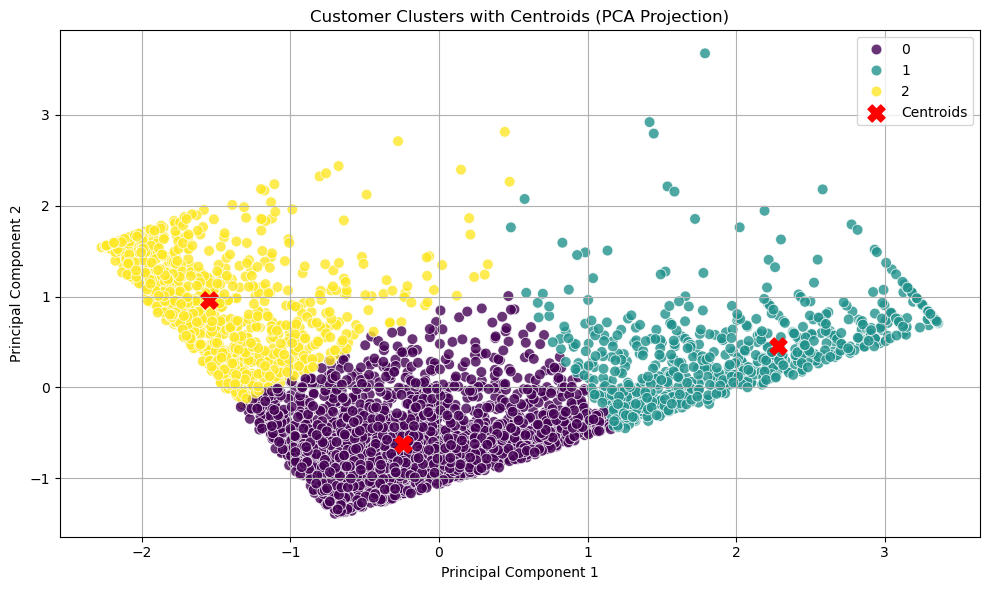

In [59]:
# Plot cluster centroids

# Apply PCA to RFM-scaled data and centroids
kmeans = KMeans(n_clusters=best_k,random_state=42)
y_means = kmeans.fit_predict(rfm_scaled)

pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)
centroids_pca = pca.transform(kmeans.cluster_centers_)

# Create a DataFrame for plotting
rfm_pca_df = pd.DataFrame(rfm_pca, columns=['PC1', 'PC2'])
rfm_pca_df['Cluster'] = rfm['Cluster'].values

# Plot clusters + centroids
plt.figure(figsize=(10, 6))

# Plot the clusters
sns.scatterplot(
    data=rfm_pca_df,
    x='PC1', y='PC2',
    hue='Cluster',
    palette='viridis',
    s=60,
    alpha=0.8
)

# Plot the centroids
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    c='red',
    s=150,
    marker='X',
    label='Centroids'
)

plt.title("Customer Clusters with Centroids (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 7.Product recommendation system [item-based collaborative filtering]

In [60]:
data.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Total_amount'],
      dtype='object')

In [61]:
recom_df = data.pivot_table(index='CustomerID',values='Quantity',columns='Description',aggfunc='sum',fill_value=0)

In [62]:
recom_df

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
CustomerID,,,,,,,,,,,,,,,,,,,,,
12346.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12347.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12348.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12349.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12350.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18280.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
18281.0,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
18282.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [63]:
recom_df.columns

Index([' 4 PURPLE FLOCK DINNER CANDLES', ' 50'S CHRISTMAS GIFT BAG LARGE',
       ' DOLLY GIRL BEAKER', ' I LOVE LONDON MINI BACKPACK',
       ' I LOVE LONDON MINI RUCKSACK', ' NINE DRAWER OFFICE TIDY',
       ' OVAL WALL MIRROR DIAMANTE ', ' RED SPOT GIFT BAG LARGE',
       ' SET 2 TEA TOWELS I LOVE LONDON ', ' SPACEBOY BABY GIFT SET',
       ...
       'ZINC STAR T-LIGHT HOLDER ', 'ZINC SWEETHEART SOAP DISH',
       'ZINC SWEETHEART WIRE LETTER RACK', 'ZINC T-LIGHT HOLDER STAR LARGE',
       'ZINC T-LIGHT HOLDER STARS LARGE', 'ZINC T-LIGHT HOLDER STARS SMALL',
       'ZINC TOP  2 DOOR WOODEN SHELF ', 'ZINC WILLIE WINKIE  CANDLE STICK',
       'ZINC WIRE KITCHEN ORGANISER', 'ZINC WIRE SWEETHEART LETTER TRAY'],
      dtype='object', name='Description', length=3877)

In [64]:
s = np.array(recom_df.columns)
s

array([' 4 PURPLE FLOCK DINNER CANDLES', " 50'S CHRISTMAS GIFT BAG LARGE",
       ' DOLLY GIRL BEAKER', ..., 'ZINC WILLIE WINKIE  CANDLE STICK',
       'ZINC WIRE KITCHEN ORGANISER', 'ZINC WIRE SWEETHEART LETTER TRAY'],
      dtype=object)

In [65]:
column_name = []
for i in s:
    column_name.append(str.strip(i))
column_name

['4 PURPLE FLOCK DINNER CANDLES',
 "50'S CHRISTMAS GIFT BAG LARGE",
 'DOLLY GIRL BEAKER',
 'I LOVE LONDON MINI BACKPACK',
 'I LOVE LONDON MINI RUCKSACK',
 'NINE DRAWER OFFICE TIDY',
 'OVAL WALL MIRROR DIAMANTE',
 'RED SPOT GIFT BAG LARGE',
 'SET 2 TEA TOWELS I LOVE LONDON',
 'SPACEBOY BABY GIFT SET',
 'TOADSTOOL BEDSIDE LIGHT',
 'TRELLIS COAT RACK',
 '10 COLOUR SPACEBOY PEN',
 '12 COLOURED PARTY BALLOONS',
 '12 DAISY PEGS IN WOOD BOX',
 '12 EGG HOUSE PAINTED WOOD',
 '12 HANGING EGGS HAND PAINTED',
 '12 IVORY ROSE PEG PLACE SETTINGS',
 '12 MESSAGE CARDS WITH ENVELOPES',
 '12 PENCIL SMALL TUBE WOODLAND',
 '12 PENCILS SMALL TUBE RED RETROSPOT',
 '12 PENCILS SMALL TUBE SKULL',
 '12 PENCILS TALL TUBE POSY',
 '12 PENCILS TALL TUBE RED RETROSPOT',
 '12 PENCILS TALL TUBE SKULLS',
 '12 PENCILS TALL TUBE WOODLAND',
 '12 PINK HEN+CHICKS IN BASKET',
 '12 PINK ROSE PEG PLACE SETTINGS',
 '12 RED ROSE PEG PLACE SETTINGS',
 '15 PINK FLUFFY CHICKS IN BOX',
 '15CM CHRISTMAS GLASS BALL 20 LIGHTS',
 '16 P

In [66]:
from sklearn.metrics.pairwise import cosine_similarity

In [67]:
cos_np_array = cosine_similarity(recom_df.T,recom_df.T)

In [68]:
cos_np_array

array([[1.00000000e+00, 0.00000000e+00, 2.10108211e-05, ...,
        1.31283358e-02, 0.00000000e+00, 2.59367717e-03],
       [0.00000000e+00, 1.00000000e+00, 3.53349047e-03, ...,
        1.12377488e-02, 0.00000000e+00, 2.97932034e-02],
       [2.10108211e-05, 3.53349047e-03, 1.00000000e+00, ...,
        8.22946311e-01, 9.68952136e-05, 6.66531857e-03],
       ...,
       [1.31283358e-02, 1.12377488e-02, 8.22946311e-01, ...,
        1.00000000e+00, 6.98581182e-03, 2.46096087e-02],
       [0.00000000e+00, 0.00000000e+00, 9.68952136e-05, ...,
        6.98581182e-03, 1.00000000e+00, 1.19612129e-01],
       [2.59367717e-03, 2.97932034e-02, 6.66531857e-03, ...,
        2.46096087e-02, 1.19612129e-01, 1.00000000e+00]])

In [69]:
cos_df = pd.DataFrame(cos_np_array,index=column_name,columns=column_name)

In [70]:
cos_df

,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
4 PURPLE FLOCK DINNER CANDLES,1.000000,0.000000,0.000021,0.000227,0.000000,0.000000,0.020155,0.000000,0.000262,0.063396,...,0.000000,0.001368,0.015886,0.001767,0.000000,0.002846,0.000000,0.013128,0.000000,0.002594
50'S CHRISTMAS GIFT BAG LARGE,0.000000,1.000000,0.003533,0.004001,0.000000,0.020034,0.027433,0.900849,0.119031,0.013380,...,0.000000,0.001718,0.015572,0.018032,0.000000,0.015710,0.000000,0.011238,0.000000,0.029793
DOLLY GIRL BEAKER,0.000021,0.003533,1.000000,0.870851,0.980561,0.006296,0.005302,0.003034,0.001765,0.411331,...,0.000000,0.000043,0.002869,0.344923,0.000000,0.525860,0.000000,0.822946,0.000097,0.006665
I LOVE LONDON MINI BACKPACK,0.000227,0.004001,0.870851,1.000000,0.883883,0.019879,0.004904,0.004043,0.008270,0.382056,...,0.000000,0.001409,0.004197,0.310017,0.000000,0.471717,0.000000,0.749210,0.000000,0.010393
I LOVE LONDON MINI RUCKSACK,0.000000,0.000000,0.980561,0.883883,1.000000,0.000000,0.000000,0.000000,0.000000,0.410578,...,0.000000,0.000000,0.000000,0.347021,0.000000,0.530836,0.000000,0.837170,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZINC T-LIGHT HOLDER STARS SMALL,0.002846,0.015710,0.525860,0.471717,0.530836,0.016877,0.129563,0.015265,0.001125,0.231796,...,0.014745,0.009731,0.108995,0.585205,0.020853,1.000000,0.006385,0.483930,0.002333,0.133134
ZINC TOP 2 DOOR WOODEN SHELF,0.000000,0.000000,0.000000,0.000000,0.000000,0.023187,0.056523,0.000000,0.000367,0.000000,...,0.000000,0.000000,0.013708,0.025044,0.000000,0.006385,1.000000,0.013216,0.000000,0.000000
ZINC WILLIE WINKIE CANDLE STICK,0.013128,0.011238,0.822946,0.749210,0.837170,0.016811,0.022624,0.012923,0.000599,0.373859,...,0.000000,0.022943,0.028676,0.324528,0.000000,0.483930,0.013216,1.000000,0.006986,0.024610
ZINC WIRE KITCHEN ORGANISER,0.000000,0.000000,0.000097,0.000000,0.000000,0.000000,0.003873,0.000000,0.000000,0.013535,...,0.000000,0.353230,0.061989,0.006864,0.000000,0.002333,0.000000,0.006986,1.000000,0.119612


In [71]:
cos_df.columns

Index(['4 PURPLE FLOCK DINNER CANDLES', '50'S CHRISTMAS GIFT BAG LARGE',
       'DOLLY GIRL BEAKER', 'I LOVE LONDON MINI BACKPACK',
       'I LOVE LONDON MINI RUCKSACK', 'NINE DRAWER OFFICE TIDY',
       'OVAL WALL MIRROR DIAMANTE', 'RED SPOT GIFT BAG LARGE',
       'SET 2 TEA TOWELS I LOVE LONDON', 'SPACEBOY BABY GIFT SET',
       ...
       'ZINC STAR T-LIGHT HOLDER', 'ZINC SWEETHEART SOAP DISH',
       'ZINC SWEETHEART WIRE LETTER RACK', 'ZINC T-LIGHT HOLDER STAR LARGE',
       'ZINC T-LIGHT HOLDER STARS LARGE', 'ZINC T-LIGHT HOLDER STARS SMALL',
       'ZINC TOP  2 DOOR WOODEN SHELF', 'ZINC WILLIE WINKIE  CANDLE STICK',
       'ZINC WIRE KITCHEN ORGANISER', 'ZINC WIRE SWEETHEART LETTER TRAY'],
      dtype='object', length=3877)

In [72]:
def product_recommedation(product_name,cos_df,top_n=6):
    if product_name not in cos_df.columns:
        return f"Product '{product_name}' not found in dataset."
    products = cos_df[product_name].sort_values(ascending=False)
    top_products = products.iloc[1:top_n]
    return top_products

In [73]:
product_recommedation('DOLLY GIRL BEAKER', cos_df)

SPACEBOY BEAKER                       0.991035
ROUND SNACK BOXES SET OF4 WOODLAND    0.983787
FOOD CONTAINER SET 3 LOVE HEART       0.983269
SET 12 COLOURING PENCILS DOILEY       0.980561
SET 36 COLOURING PENCILS DOILEY       0.980561
Name: DOLLY GIRL BEAKER, dtype: float64

In [74]:
# Save model

import pickle

# Save KMeans model
with open('kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

# Save Scaler used for RFM
with open('rfm_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('Product_recommendation.pkl', 'wb') as f:
    pickle.dump(cos_df,f)